# Cohort & Retention Analysis

**Goal:** Analyze customer retention patterns over time using cohort analysis to understand:
- How long customers stay active (retention rate)
- Which cohorts perform better (quality comparison)
- Revenue retention vs. customer retention
- When customers typically churn

**Inputs:**
- `online_retail_clean.parquet` (cleaned transaction data from 01_eda_rfm.ipynb)

**Outputs:**
- Monthly cohort retention heatmap
- Average retention curve (decay analysis)
- Revenue retention analysis
- Actionable insights for retention strategy

**Key Concept:**
> **Cohort** = A group of customers who made their first purchase in the same month  
> **Retention Rate** = % of customers from a cohort who return in subsequent months

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_parquet("../data/online_retail_clean.parquet")
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,InvoiceYear,InvoiceMonth,InvoiceDay,InvoiceWeek,InvoiceStartMonth,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,2009,12,1,49,2009-12-01,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,2009,12,1,49,2009-12-01,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,2009,12,1,49,2009-12-01,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,2009,12,1,49,2009-12-01,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,2009,12,1,49,2009-12-01,30.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 779425 entries, 0 to 779424
Data columns (total 14 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   Invoice            779425 non-null  object        
 1   StockCode          779425 non-null  object        
 2   Description        779425 non-null  object        
 3   Quantity           779425 non-null  int64         
 4   InvoiceDate        779425 non-null  datetime64[ns]
 5   Price              779425 non-null  float64       
 6   Customer ID        779425 non-null  int64         
 7   Country            779425 non-null  object        
 8   InvoiceYear        779425 non-null  int32         
 9   InvoiceMonth       779425 non-null  int32         
 10  InvoiceDay         779425 non-null  int32         
 11  InvoiceWeek        779425 non-null  UInt32        
 12  InvoiceStartMonth  779425 non-null  datetime64[ms]
 13  TotalPrice         779425 non-null  float64 

# Cohort Analysis Setup

## Prepare Transaction Data

Create a transaction-level table with unique customer-invoice combinations for cohort assignment.

In [4]:
tx = df[["Customer ID", "Invoice", "InvoiceDate", "InvoiceStartMonth"]].drop_duplicates()
tx

,Customer ID,Invoice,InvoiceDate,InvoiceStartMonth
0,13085,489434,2009-12-01 07:45:00,2009-12-01
8,13085,489435,2009-12-01 07:46:00,2009-12-01
12,13078,489436,2009-12-01 09:06:00,2009-12-01
31,15362,489437,2009-12-01 09:08:00,2009-12-01
54,18102,489438,2009-12-01 09:24:00,2009-12-01
...,...,...,...,...
779380,13777,581583,2011-12-09 12:23:00,2011-12-01
779382,13777,581584,2011-12-09 12:25:00,2011-12-01
779384,15804,581585,2011-12-09 12:31:00,2011-12-01
779405,13113,581586,2011-12-09 12:49:00,2011-12-01


## Assign Cohort Month

Identify each customer's first purchase month (cohort assignment).  
This determines which cohort group they belong to for retention tracking.

In [5]:
cohort = (
    tx.groupby("Customer ID")["InvoiceStartMonth"]
    .min()
    .reset_index()
    .rename(columns={"InvoiceStartMonth" : "CohortMonth"})
)

tx = tx.merge(cohort, on= "Customer ID", how = "left")
tx[["Customer ID", "InvoiceStartMonth", "CohortMonth"]].head()

,Customer ID,InvoiceStartMonth,CohortMonth
0,13085,2009-12-01,2009-12-01
1,13085,2009-12-01,2009-12-01
2,13078,2009-12-01,2009-12-01
3,15362,2009-12-01,2009-12-01
4,18102,2009-12-01,2009-12-01


## Calculate Cohort Index

Calculate how many months after their first purchase each transaction occurred.  
CohortIndex = 1 means the customer's first purchase month, CohortIndex = 2 means one month later, etc.

**Formula:**  
`CohortIndex = (Transaction Year - Cohort Year) × 12 + (Transaction Month - Cohort Month) + 1`

In [6]:
tx["CohortIndex"] = (
    (tx["InvoiceStartMonth"].dt.year - tx["CohortMonth"].dt.year) * 12 
    + (tx["InvoiceStartMonth"].dt.month - tx["CohortMonth"].dt.month) + 1 
)

tx.head()

,Customer ID,Invoice,InvoiceDate,InvoiceStartMonth,CohortMonth,CohortIndex
0,13085,489434,2009-12-01 07:45:00,2009-12-01,2009-12-01,1
1,13085,489435,2009-12-01 07:46:00,2009-12-01,2009-12-01,1
2,13078,489436,2009-12-01 09:06:00,2009-12-01,2009-12-01,1
3,15362,489437,2009-12-01 09:08:00,2009-12-01,2009-12-01,1
4,18102,489438,2009-12-01 09:24:00,2009-12-01,2009-12-01,1


# Customer Retention Analysis

## Build Cohort Matrix & Calculate Retention Rates

Create a cohort matrix showing how many customers from each cohort return in subsequent months.  
Retention rate = (Customers in Month N) / (Customers in Month 1)

**Example:**  
If 2021-01 cohort started with 100 customers and 40 returned in Month 2, retention = 40%.

In [7]:
cohort_counts = (
    tx.groupby(["CohortMonth", "CohortIndex"])["Customer ID"]
      .nunique()
      .reset_index()
      .pivot(index="CohortMonth", columns="CohortIndex", values="Customer ID")
)

retention = cohort_counts.divide(cohort_counts.iloc[:, 0], axis=0)

cohort_counts.head(), retention.head()


(CohortIndex     1      2      3      4      5      6      7      8      9   \
 CohortMonth                                                                  
 2009-12-01   955.0  337.0  319.0  406.0  363.0  343.0  360.0  327.0  321.0   
 2010-01-01   383.0   79.0  119.0  117.0  101.0  115.0   99.0   88.0  107.0   
 2010-02-01   374.0   89.0   84.0  109.0   92.0   75.0   72.0  107.0   95.0   
 2010-03-01   443.0   84.0  102.0  107.0  103.0   90.0  109.0  134.0  122.0   
 2010-04-01   294.0   57.0   57.0   48.0   54.0   66.0   81.0   77.0   31.0   
 
 CohortIndex     10  ...     16     17     18     19     20     21     22  \
 CohortMonth         ...                                                    
 2009-12-01   346.0  ...  289.0  251.0  289.0  270.0  248.0  244.0  301.0   
 2010-01-01   122.0  ...   58.0   90.0   76.0   71.0   75.0   93.0   74.0   
 2010-02-01   103.0  ...   75.0   60.0   61.0   54.0   86.0   86.0   61.0   
 2010-03-01    48.0  ...   75.0   77.0   69.0   78.0   89.0 

## Visualize Retention Heatmap

Heatmap showing retention rates across cohorts and months.  
Each row = one cohort, each column = months since first purchase.  
Darker green = higher retention, lighter = lower retention.

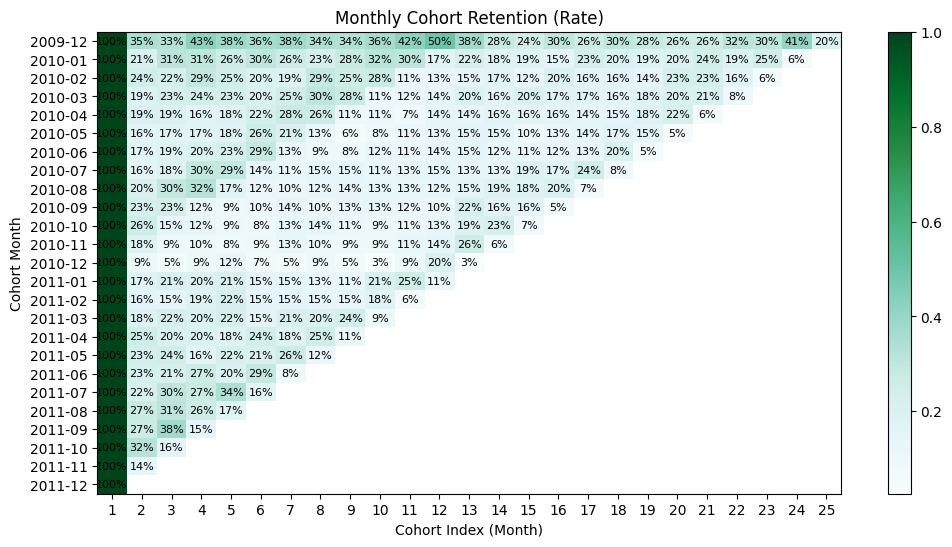

In [8]:
plt.figure(figsize=(12, 6))
plt.imshow(retention, aspect="auto", cmap ='BuGn')
plt.title("Monthly Cohort Retention (Rate)")
plt.xlabel("Cohort Index (Month)")
plt.ylabel("Cohort Month")
plt.colorbar()

plt.xticks(
    ticks=np.arange(retention.shape[1]),
    labels=np.arange(1, retention.shape[1] + 1)
)
plt.yticks(range(len(retention.index)), [d.strftime("%Y-%m") for d in retention.index])

for i in range(retention.shape[0]):
    for j in range(retention.shape[1]):
        v = retention.iloc[i, j]
        if pd.notna(v):
            plt.text(j, i, f"{v:.0%}", ha="center", va="center", fontsize=8)

plt.show()


## Additional Analyses

### Cohort Size Distribution

Analyze the size of each cohort (number of customers who made their first purchase in each month).  
Larger cohorts may indicate seasonal effects or successful marketing campaigns.

In [9]:
cohort_size = cohort_counts.iloc[:,1].sort_index()
cohort_size

CohortMonth
2009-12-01    337.0
2010-01-01     79.0
2010-02-01     89.0
2010-03-01     84.0
2010-04-01     57.0
2010-05-01     40.0
2010-06-01     47.0
2010-07-01     29.0
2010-08-01     33.0
2010-09-01     55.0
2010-10-01     97.0
2010-11-01     57.0
2010-12-01      7.0
2011-01-01     12.0
2011-02-01     20.0
2011-03-01     33.0
2011-04-01     27.0
2011-05-01     26.0
2011-06-01     25.0
2011-07-01     22.0
2011-08-01     29.0
2011-09-01     51.0
2011-10-01     71.0
2011-11-01     27.0
2011-12-01      NaN
Name: 2, dtype: float64

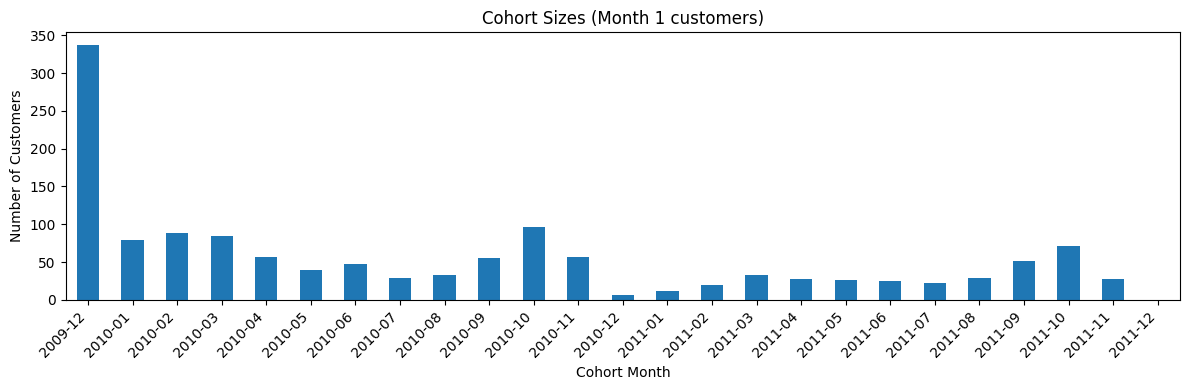

In [10]:
# Format x-axis labels as YYYY-MM
ax = cohort_size.plot(kind="bar", figsize=(12,4), title="Cohort Sizes (Month 1 customers)")

# Clean date labels (remove time part)
ax.set_xticklabels([d.strftime("%Y-%m") for d in cohort_size.index])
plt.xticks(rotation=45, ha='right')
plt.xlabel("Cohort Month")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

### Average Retention Curve

Calculate the average retention rate across all cohorts for each time period.  
This shows the typical customer lifecycle and identifies critical drop-off points.

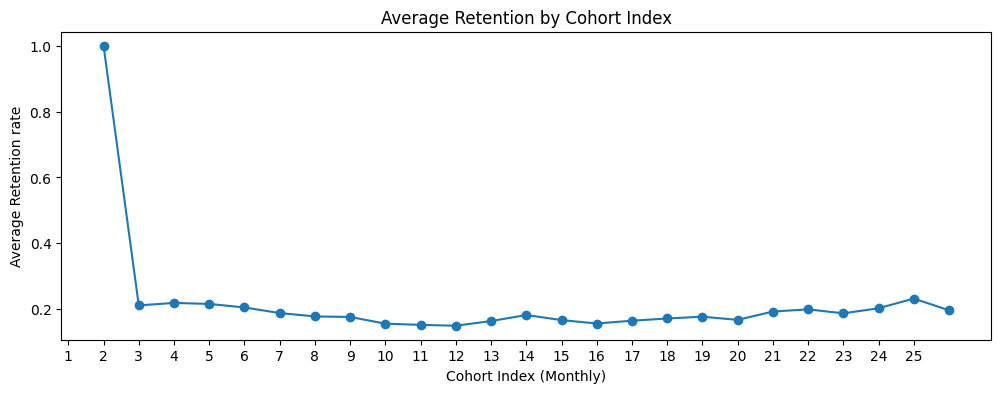

In [11]:
avg_retention = retention.mean(axis = 0)
avg_retention.plot(marker = "o", figsize = (12,4), title = "Average Retention by Cohort Index")
plt.xlabel("Cohort Index (Monthly)")
plt.ylabel("Average Retention rate")
plt.xticks(range(len(avg_retention)), range(1, len(avg_retention) + 1))
plt.show()


# Revenue Retention Analysis

## Calculate Revenue-Based Retention

Instead of counting customers, calculate how much revenue each cohort generates over time.  
Revenue retention can differ from customer retention if returning customers spend more (or less) than average.

**Key comparison:**  
- Customer retention = 30% but Revenue retention = 50% → Retained customers are high-value
- Customer retention = 30% but Revenue retention = 20% → Losing high-value customers

In [12]:
tx["TotalPrice"] = df["TotalPrice"]
rev = (tx.groupby(["CohortMonth", "CohortIndex"])["TotalPrice"].sum()
      .reset_index()
      .pivot(index = "CohortMonth", columns = "CohortIndex", values = "TotalPrice"))
rev_retention = rev.divide(rev.iloc[:, 0], axis = 0)
rev_retention.head()

CohortIndex,1,2,3,4,5,6,7,8,9,10,...,16,17,18,19,20,21,22,23,24,25
CohortMonth,,,,,,,,,,,,,,,,,,,,,
2009-12-01,1.0,0.613715,0.206373,0.487338,0.677042,0.340195,0.413629,0.259970,0.341165,0.428111,...,0.356412,0.369457,0.391261,0.337045,0.326090,0.408520,0.455871,0.924991,1.018331,0.177609
2010-01-01,1.0,0.085484,0.201444,0.316940,0.135433,0.160810,0.138719,0.149196,0.211679,0.242374,...,0.202033,0.174611,0.107156,0.198374,0.164382,0.218724,0.433207,0.372058,0.019706,NaN
2010-02-01,1.0,0.403672,0.441428,0.343267,0.246332,0.202611,0.227216,0.417360,0.407359,0.318738,...,0.324674,0.207216,0.306074,0.272206,0.277756,0.755630,0.350695,0.061431,NaN,NaN
2010-03-01,1.0,0.478313,0.278359,0.261985,0.172263,0.221750,0.508022,0.386918,0.481740,0.111530,...,0.137760,0.252072,0.133694,0.157237,0.406204,0.581314,0.054832,NaN,NaN,NaN
2010-04-01,1.0,0.076136,0.058934,0.054083,0.070033,0.102653,0.144709,0.117279,0.033927,0.063845,...,0.112865,0.059428,0.065933,0.147700,0.149288,0.027680,NaN,NaN,NaN,NaN


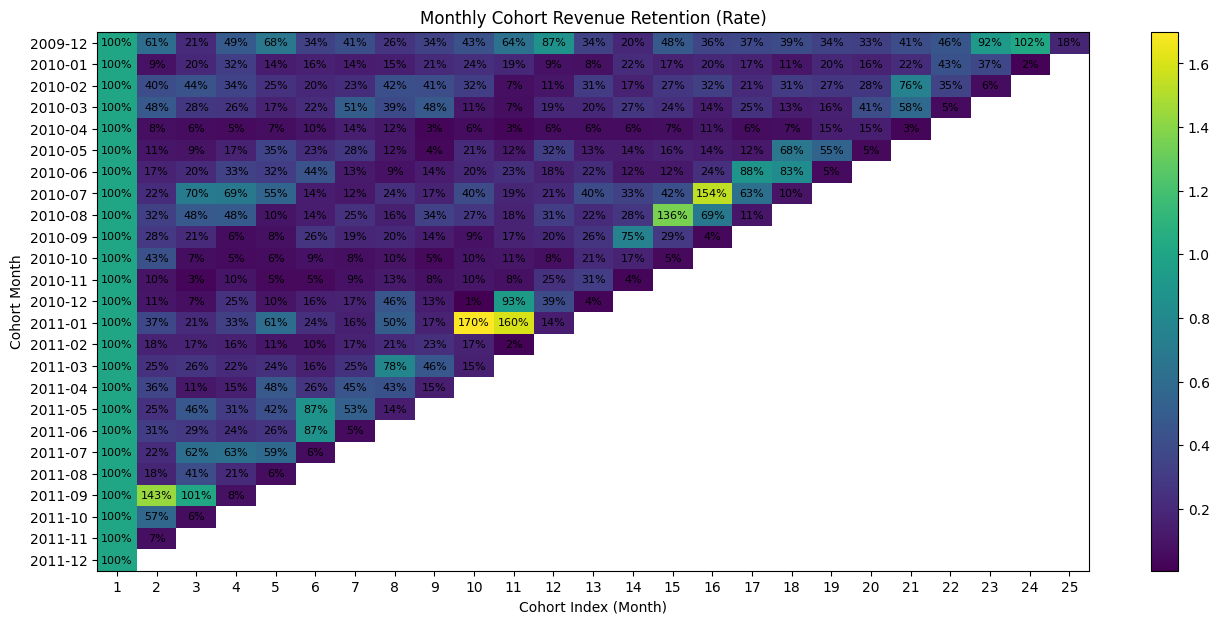

In [13]:
plt.figure(figsize=(16, 7))
plt.imshow(rev_retention, aspect="auto")
plt.title("Monthly Cohort Revenue Retention (Rate)")
plt.xlabel("Cohort Index (Month)")
plt.ylabel("Cohort Month")
plt.colorbar()

plt.yticks(range(len(rev_retention.index)), [d.strftime("%Y-%m") for d in rev_retention.index])
plt.xticks(
    ticks=np.arange(rev_retention.shape[1]),
    labels=np.arange(1, rev_retention.shape[1] + 1)
)

for i in range(rev_retention.shape[0]):
    for j in range(rev_retention.shape[1]):
        v = rev_retention.iloc[i, j]
        if pd.notna(v):
            plt.text(j, i, f"{v:.0%}", ha="center", va="center", fontsize=8)

plt.show()


In [14]:
rev_retention.iloc[:5,:6]

CohortIndex,1,2,3,4,5,6
CohortMonth,,,,,,
2009-12-01,1.0,0.613715,0.206373,0.487338,0.677042,0.340195
2010-01-01,1.0,0.085484,0.201444,0.316940,0.135433,0.160810
2010-02-01,1.0,0.403672,0.441428,0.343267,0.246332,0.202611
2010-03-01,1.0,0.478313,0.278359,0.261985,0.172263,0.221750
2010-04-01,1.0,0.076136,0.058934,0.054083,0.070033,0.102653


# Key Insights & Business Recommendations

## Summary of Findings

### 1. Customer Retention Pattern
- **Month 1 → 2 Critical Drop:** ~75-80% of customers don't return after first purchase
- **Stabilization Point:** Retention stabilizes around 15-25% after Month 6
- **Long-term Loyalty:** ~20% of customers remain active after 12+ months

### 2. Revenue vs. Customer Retention
- Some cohorts show **higher revenue retention** than customer retention
- This indicates retained customers spend more over time (upsell/cross-sell success)
- Cohorts like 2010-01 show revenue retention >100% in later months → Surviving customers are high-value

### 3. Cohort Quality Variation
- **Best cohorts:** 2009-12 (holiday season) - largest and relatively good retention
- **Seasonal pattern:** End-of-year cohorts tend to be larger (holiday shopping effect)

### 4. Critical Retention Window
- The first **30-60 days** are crucial for customer retention
- Most churn happens in Month 2 (second purchase decision point)

## Business Recommendations

### Immediate Actions:
1. **Implement Welcome Series:** Send targeted emails in first 7-14 days after purchase
2. **Second Purchase Incentive:** Offer 10-15% discount for second purchase within 30 days
3. **Month 2 Re-engagement:** Launch automated campaign at day 25-30 for customers who haven't returned

### Strategic Priorities:
1. **Focus on High-Value Retention:** Since revenue retention > customer retention, prioritize retaining high-spenders
2. **Holiday Acquisition:** Invest more in customer acquisition during Nov-Dec (best cohort quality)
3. **VIP Program Integration:** Connect with RFM segments - target "Champions" and "Loyal" for retention campaigns